# Linear Regression - ElasticNet tuning

### __Introduction__

- We will start by using this model mostly as a baseline for our other models.
- A priori, we think that this will most likely not be our best performing model, mostly because it assumes linearity of features, which may not be the case. 

## 1. 

In [1]:
# 1) Imports 
import numpy as np
import pandas as pd

from datetime import datetime

from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.model_selection import ParameterSampler

# 2) Import pre processing helpers
#    -> this should define: full_train_dataset, cat_feat, num_feat,
#       basic_string_transformer, def_string_basic_transformer,
#       preprocess_categorical, MyTargetEncoder, MyOneHotEncoder, etc.
%run 05_0_preproc_helpers.ipynb  
%run 05_0.1_visualization_helpers.ipynb  

# 3) Define target
TARGET_COL = "price"

# 4) Separate X and y from the treated dataset
y = full_train_dataset[TARGET_COL].copy()
X = full_train_dataset.drop(columns=[TARGET_COL]).copy()

# Numerical and categorical features (splitted in pre processing)
numeric_features = num_feat
categorical_features = cat_feat

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Num features:", numeric_features)
print("Cat features:", categorical_features)

X shape: (75973, 10)
y shape: (75973,)
Num features: ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'previousOwners']
Cat features: ['Brand', 'model', 'transmission', 'fuelType']


In [2]:
valid_transmissions = ["MANUAL", "AUTOMATIC", "SEMIAUTO"]
valid_fueltypes    = ["PETROL", "DIESEL", "HYBRID"]

# KFold config
N_SPLITS = 8
RANDOM_STATE = 42

kf = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

elastic_param_distributions = {
    "alpha": np.logspace(-5, 1, 40),
    "l1_ratio": np.linspace(0.1, 0.9, 9)
}

N_RANDOM_CONFIGS_EN = 60

elastic_sampler = ParameterSampler(
    elastic_param_distributions,
    n_iter=N_RANDOM_CONFIGS_EN,
    random_state=RANDOM_STATE
)

elastic_search_results = []

elastic_best_rmse = np.inf
elastic_best_config_rmse = None

elastic_best_mae = np.inf
elastic_best_config_mae = None

elastic_best_combo = np.inf
elastic_best_config_combo = None

elastic_log_path = "elasticnet_random_search_log.txt"

with open(elastic_log_path, "w", encoding="utf-8") as log_file:

    def log_en(msg: str):
        log_file.write(datetime.now().strftime("[%Y-%m-%d %H:%M:%S] ") + msg + "\n")
        log_file.flush()

    log_en("# =============================")
    log_en("# START OF RANDOM SEARCH ElasticNet")
    log_en("# =============================")
    log_en(f"N_SPLITS = {N_SPLITS}, N_RANDOM_CONFIGS = {N_RANDOM_CONFIGS_EN}")
    log_en(f"param_distributions = {elastic_param_distributions}")

    for config_id, params in enumerate(elastic_sampler, start=1):
        log_en("")
        log_en(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS_EN} ########")
        log_en(f"Parameters: {params}")

        fold_rmses_val = []
        fold_maes_val  = []
        fold_r2s_val   = []
        fold_bias_val  = []

        fold_rmses_tr = []
        fold_maes_tr  = []
        fold_r2s_tr   = []
        fold_bias_tr  = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
            log_en("")
            log_en(f"[CONFIG {config_id}] ==== FOLD {fold}/{N_SPLITS} ====")

            X_train = X.iloc[train_idx].copy()
            X_val   = X.iloc[val_idx].copy()
            y_train = y.iloc[train_idx].copy()
            y_val   = y.iloc[val_idx].copy()

            # numeric preprocessing
            year_state = fit_year_median(X_train, year_col="year", model_col="model")
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
            X_train = transform_mileage_imputer(X_train, state=mileage_state)
            X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

            engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            tax_state = fit_tax_imputer(X_train, tax_col="tax", do_abs=True)
            X_train = transform_tax_imputer(X_train, state=tax_state)
            X_val   = transform_tax_imputer(X_val,   state=tax_state)

            mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            owners_state = fit_previous_owners_imputer(
                X_train, owners_col="previousOwners", year_col="year", mileage_col="mileage"
            )
            X_train = transform_previous_owners_imputer(X_train, state=owners_state)
            X_val   = transform_previous_owners_imputer(X_val,   state=owners_state)

            # resolvers
            brand_state = fit_ambiguous_brand_resolver(
                train_df=X_train, valid_brands=valid_brands,
                brand_col="Brand", model_col="model", year_col="year"
            )
            X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
            X_val,   _, _ = transform_ambiguous_brands(X_val,   brand_state)

            model_state = fit_invalid_model_resolver(
                train_df=X_train, valid_models_by_brand=valid_models_by_brand,
                brand_col="Brand", model_col="model", year_col="year",
                fuel_col="fuelType", mpg_col="mpg"
            )
            X_train, _, _ = transform_invalid_models(X_train, model_state)
            X_val,   _, _ = transform_invalid_models(X_val,   model_state)

            transm_state = fit_transmission_resolver(
                train_df=X_train, valid_transmissions=valid_transmissions,
                transm_col="transmission", brand_col="Brand",
                model_col="model", fuel_col="fuelType"
            )
            X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
            X_val,   _, _ = transform_transmission_resolver(X_val,   transm_state)

            fuel_state = fit_fueltype_resolver(
                train_df=X_train, valid_fueltypes=valid_fueltypes,
                fuel_col="fuelType", brand_col="Brand",
                model_col="model", transm_col="transmission"
            )
            X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
            X_val,   _, _ = transform_fueltype_resolver(X_val,   fuel_state)

            # encoding
            high_card_features = ["Brand", "model"]
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train)
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features])
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

            # scaling
            scaler = StandardScaler()
            X_train_num = scaler.fit_transform(X_train[numeric_features])
            X_val_num   = scaler.transform(X_val[numeric_features])

            X_train_num_df = pd.DataFrame(
                X_train_num,
                index=X_train.index,
                columns=[f"num_{col}" for col in numeric_features]
            )
            X_val_num_df = pd.DataFrame(
                X_val_num,
                index=X_val.index,
                columns=[f"num_{col}" for col in numeric_features]
            )

            X_train_final = pd.concat([X_train_num_df, X_train_cat], axis=1)
            X_val_final   = pd.concat([X_val_num_df,   X_val_cat],   axis=1)

            # model
            en = ElasticNet(
                alpha=params["alpha"],
                l1_ratio=params["l1_ratio"],
                fit_intercept=True,
                max_iter=10000
            )

            log_en(f"[C{config_id}|F{fold}] Training ElasticNet...")
            en.fit(X_train_final, y_train)

            y_pred_train = en.predict(X_train_final)
            y_pred_val   = en.predict(X_val_final)

            mse_val  = mean_squared_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mse_val)
            mae_val  = mean_absolute_error(y_val, y_pred_val)
            r2_val   = r2_score(y_val, y_pred_val)
            bias_val = float(np.mean(y_pred_val - y_val))

            mse_tr  = mean_squared_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mse_tr)
            mae_tr  = mean_absolute_error(y_train, y_pred_train)
            r2_tr   = r2_score(y_train, y_pred_train)
            bias_tr = float(np.mean(y_pred_train - y_train))

            log_en(f"[C{config_id}|F{fold}] TRAIN -> RMSE: {rmse_tr:.2f} | MAE: {mae_tr:.2f} | R2: {r2_tr:.4f} | Bias(pred-true): {bias_tr:.2f}")
            log_en(f"[C{config_id}|F{fold}] VAL   -> RMSE: {rmse_val:.2f} | MAE: {mae_val:.2f} | R2: {r2_val:.4f} | Bias(pred-true): {bias_val:.2f}")

            fold_rmses_tr.append(rmse_tr)
            fold_maes_tr.append(mae_tr)
            fold_r2s_tr.append(r2_tr)
            fold_bias_tr.append(bias_tr)

            fold_rmses_val.append(rmse_val)
            fold_maes_val.append(mae_val)
            fold_r2s_val.append(r2_val)
            fold_bias_val.append(bias_val)

        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)

        mean_rmse_tr = np.mean(fold_rmses_tr)
        mean_mae_tr  = np.mean(fold_maes_tr)
        mean_r2_tr   = np.mean(fold_r2s_tr)
        mean_bias_tr = np.mean(fold_bias_tr)

        combo_score = 0.5 * mean_rmse_val + 0.5 * mean_mae_val

        log_en(f"Config {config_id} - Avg TRAIN RMSE: {mean_rmse_tr:.2f} | MAE: {mean_mae_tr:.2f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.2f}")
        log_en(f"Config {config_id} - Avg VAL   RMSE: {mean_rmse_val:.2f} | MAE: {mean_mae_val:.2f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.2f}")
        log_en(f"Config {config_id} - Combined score (0.5*RMSE + 0.5*MAE) [VAL]: {combo_score:.2f}")

        elastic_search_results.append({
            "config_id": config_id,
            **params,
            "rmse_train_mean": mean_rmse_tr,
            "mae_train_mean": mean_mae_tr,
            "r2_train_mean": mean_r2_tr,
            "bias_train_mean": mean_bias_tr,
            "rmse_mean": mean_rmse_val,
            "mae_mean": mean_mae_val,
            "r2_mean": mean_r2_val,
            "bias_mean": mean_bias_val,
            "combo_score": combo_score,
        })

        if mean_rmse_val < elastic_best_rmse:
            elastic_best_rmse = mean_rmse_val
            elastic_best_config_rmse = {**params}
            log_en(f"[NEW BEST RMSE] Config {config_id} with avg RMSE (VAL) = {elastic_best_rmse:.2f}")

        if mean_mae_val < elastic_best_mae:
            elastic_best_mae = mean_mae_val
            elastic_best_config_mae = {**params}
            log_en(f"[NEW BEST MAE] Config {config_id} with avg MAE (VAL) = {elastic_best_mae:.2f}")

        if combo_score < elastic_best_combo:
            elastic_best_combo = combo_score
            elastic_best_config_combo = {**params}
            log_en(f"[NEW BEST COMBINED] Config {config_id} with score = {elastic_best_combo:.2f}")

    log_en("")
    log_en("# =============================")
    log_en("# END OF RANDOM SEARCH ElasticNet")
    log_en("# =============================")
    log_en(f"Best configuration (min RMSE VAL): {elastic_best_config_rmse}")
    log_en(f"Best average RMSE (VAL): {elastic_best_rmse:.2f}")
    log_en(f"Best configuration (min MAE VAL): {elastic_best_config_mae}")
    log_en(f"Best average MAE  (VAL): {elastic_best_mae:.2f}")
    log_en(f"Best configuration (combined score VAL): {elastic_best_config_combo}")
    log_en(f"Best combined score (VAL): {elastic_best_combo:.2f}")

elastic_results_df = pd.DataFrame(elastic_search_results)
elastic_results_df_sorted = elastic_results_df.sort_values(by="mae_mean", ascending=True)

display(elastic_results_df_sorted.head(10))

print("\nBest configuration found (min RMSE VAL):")
print(elastic_best_config_rmse)
print("Best average RMSE (VAL):", elastic_best_rmse)

print("\nBest configuration found (min MAE VAL):")
print(elastic_best_config_mae)
print("Best average MAE (VAL):", elastic_best_mae)

print("\nBest configuration found (min 0.5*RMSE + 0.5*MAE):")
print(elastic_best_config_combo)
print("Best combined score (VAL):", elastic_best_combo)

elastic_results_df_sorted.to_csv("elasticnet_random_search_results.csv", index=False)
print(f"\nDetailed logs in: {elastic_log_path}")

/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.660e+11, tolerance: 6.343e+08
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.608e+11, tolerance: 6.312e+08
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing reg

,config_id,l1_ratio,alpha,rmse_train_mean,mae_train_mean,r2_train_mean,bias_train_mean,rmse_mean,mae_mean,r2_mean,bias_mean,combo_score
51,52,0.4,0.100000,4151.287279,2623.947315,0.818225,-5.043613e-13,4178.203218,2630.600242,0.815803,0.222654,3404.401730
8,9,0.6,0.142510,4149.978592,2624.102801,0.818340,-3.923044e-13,4176.825892,2630.744014,0.815924,0.221610,3403.784953
30,31,0.7,0.289427,4164.360037,2623.996511,0.817079,-1.688270e-13,4191.864087,2630.895939,0.814595,0.232475,3411.380013
50,51,0.8,0.587802,4181.341057,2626.633104,0.815584,-6.681111e-13,4209.450873,2633.767111,0.813035,0.244069,3421.608992
42,43,0.9,1.193777,4182.677483,2626.934419,0.815466,-7.250202e-13,4210.828678,2634.086723,0.812913,0.244714,3422.457700
25,26,0.5,0.049239,4137.821053,2628.583994,0.819403,-2.831586e-13,4163.861191,2634.948655,0.817066,0.212341,3399.404923
52,53,0.3,0.034551,4137.687616,2628.692764,0.819414,1.986981e-13,4163.715994,2635.054352,0.817079,0.212257,3399.385173
12,13,0.4,0.034551,4136.687070,2629.594524,0.819502,1.932812e-13,4162.623084,2635.931647,0.817175,0.211681,3399.277366
21,22,0.7,0.049239,4135.134373,2631.415753,0.819637,-3.800200e-14,4160.909190,2637.713158,0.817326,0.210985,3399.311174
45,46,0.8,0.070170,4134.961918,2631.664344,0.819652,-1.151757e-12,4160.717007,2637.958196,0.817343,0.210926,3399.337601



Best configuration found (min RMSE VAL):
{'l1_ratio': np.float64(0.8), 'alpha': np.float64(0.001)}
Best average RMSE (VAL): 4158.0629772251405

Best configuration found (min MAE VAL):
{'l1_ratio': np.float64(0.4), 'alpha': np.float64(0.1)}
Best average MAE (VAL): 2630.600241954019

Best configuration found (min 0.5*RMSE + 0.5*MAE):
{'l1_ratio': np.float64(0.4), 'alpha': np.float64(0.03455107294592222)}
Best combined score (VAL): 3399.2773656310146

Detailed logs in: elasticnet_random_search_log.txt


In [3]:
# Choose final hyperparameters
final_config_en = elastic_best_config_rmse
#final_config_en = {
#    "alpha": elastic_best_config_rmse["alpha"],
#    "l1_ratio": elastic_best_config_rmse["l1_ratio"]
#}
print("Final ElasticNet config used for train:", final_config_en)

print("Preparing final ElasticNet Regression training...")

# 1) PREPARE FULL TRAIN FEATURES
X_full = X.copy()
y_full = y.copy()

# a) STRING NORMALIZATION
cols_to_normalize = ["Brand", "model", "transmission", "fuelType"]

for col in cols_to_normalize:
    if col in X_full.columns:
        X_full[col] = X_full[col].apply(
            lambda x: basic_string_transformer(
                x, 
                remove_middle_spaces=True, 
                allow_extra_chars=""
            )
        )

high_card_features = ["Brand", "model"] 
low_card_features  = [c for c in categorical_features if c not in high_card_features]

# 2) NUMERIC PRE PROCESSING - FULL TRAIN
year_state = fit_year_median(X_full, year_col="year", model_col="model")
X_full = transform_year_with_model_median(X_full, state=year_state)

mileage_state = fit_mileage_imputer(X_full, mileage_col="mileage", do_abs=True)
X_full = transform_mileage_imputer(X_full, state=mileage_state)

engine_state = fit_engine_size_imputer(X_full, engine_col="engineSize")
X_full = transform_engine_size_imputer(X_full, state=engine_state)

tax_state = fit_tax_imputer(X_full, tax_col="tax", do_abs=True)
X_full = transform_tax_imputer(X_full, state=tax_state)

mpg_state = fit_mpg_imputer(X_full, mpg_col="mpg", do_abs=True)
X_full = transform_mpg_imputer(X_full, state=mpg_state)

# paint_state = fit_paint_quality_imputer(X_full, paint_col="paintQuality%")
# X_full = transform_paint_quality_imputer(X_full, state=paint_state)

owners_state = fit_previous_owners_imputer(
    X_full, owners_col="previousOwners", year_col="year", mileage_col="mileage"
)
X_full = transform_previous_owners_imputer(X_full, state=owners_state)

# 3) CATEGORICAL RESOLVERS - FULL TRAIN
brand_state = fit_ambiguous_brand_resolver(
    train_df=X_full, valid_brands=valid_brands, 
    brand_col="Brand", model_col="model", year_col="year"
)
X_full, _, brand_still_invalid_full = transform_ambiguous_brands(X_full, brand_state)
print(f"Train full - Invalid Brands remaining: {len(brand_still_invalid_full)}")

model_state = fit_invalid_model_resolver(
    train_df=X_full, valid_models_by_brand=valid_models_by_brand,
    brand_col="Brand", model_col="model", year_col="year", 
    fuel_col="fuelType", mpg_col="mpg"
)
X_full, _, model_still_invalid_full = transform_invalid_models(X_full, model_state)
print(f"Train full - Invalid Models remaining: {len(model_still_invalid_full)}")

transm_state = fit_transmission_resolver(
    train_df=X_full, valid_transmissions=valid_transmissions,
    transm_col="transmission", brand_col="Brand", 
    model_col="model", fuel_col="fuelType"
)
X_full, _, _ = transform_transmission_resolver(X_full, transm_state)

fuel_state = fit_fueltype_resolver(
    train_df=X_full, valid_fueltypes=valid_fueltypes,
    fuel_col="fuelType", brand_col="Brand", 
    model_col="model", transm_col="transmission"
)
X_full, _, _ = transform_fueltype_resolver(X_full, fuel_state)

# 4) CATEGORICAL ENCODING - FULL TRAIN
te = MyTargetEncoder(smoothing=5)
te.fit(X_full[high_card_features], y_full)
X_full_high = te.transform(X_full[high_card_features])

ohe = MyOneHotEncoder()
ohe.fit(X_full[low_card_features])
X_full_low = ohe.transform(X_full[low_card_features])

X_full_cat = pd.concat([X_full_high, X_full_low], axis=1)
print("X_full_cat shape:", X_full_cat.shape)

# 5) NUMERIC SCALING - FULL TRAIN
scaler = StandardScaler()
X_full_num = scaler.fit_transform(X_full[numeric_features])

X_full_num_df = pd.DataFrame(
    X_full_num,
    index=X_full.index,
    columns=[f"num_{col}" for col in numeric_features]
)
print("X_full_num_df shape:", X_full_num_df.shape)

# 6) FINAL MATRIX - FULL TRAIN
X_full_final = pd.concat([X_full_num_df, X_full_cat], axis=1)
print("X_full_final shape:", X_full_final.shape)

# 7) TRAIN FINAL ELASTIC NET MODEL
en_final = ElasticNet(
    alpha=final_config_en["alpha"],
    l1_ratio=final_config_en["l1_ratio"],
    fit_intercept=True,
    max_iter=10000
)

print("Training final ElasticNet Regression model on full data...")
en_final.fit(X_full_final, y_full)
print("Done.")

# 8) PREPARE TEST FEATURES
test_df = pd.read_csv("../../project_data/test.csv")

for col in cols_to_normalize:
    if col in test_df.columns:
        test_df[col] = test_df[col].apply(
            lambda x: basic_string_transformer(
                x, 
                remove_middle_spaces=True, 
                allow_extra_chars=""
            )
        )

X_test = test_df[numeric_features + categorical_features].copy()

# NUMERIC PREPROCESSING - TEST
X_test = transform_year_with_model_median(X_test, state=year_state)
X_test = transform_mileage_imputer(X_test, state=mileage_state)
X_test = transform_engine_size_imputer(X_test, state=engine_state)
X_test = transform_tax_imputer(X_test, state=tax_state)
X_test = transform_mpg_imputer(X_test, state=mpg_state)
# X_test = transform_paint_quality_imputer(X_test, state=paint_state)
X_test = transform_previous_owners_imputer(X_test, state=owners_state)

# CATEGORICAL RESOLVERS - TEST
X_test, _, _ = transform_ambiguous_brands(X_test, brand_state)
X_test, _, _ = transform_invalid_models(X_test, model_state)
X_test, _, _ = transform_transmission_resolver(X_test, transm_state)
X_test, _, _ = transform_fueltype_resolver(X_test, fuel_state)

# ENCODING - TEST
X_test_high = te.transform(X_test[high_card_features])
X_test_low  = ohe.transform(X_test[low_card_features])
X_test_cat  = pd.concat([X_test_high, X_test_low], axis=1)

# SCALING - TEST
X_test_num = scaler.transform(X_test[numeric_features])
X_test_num_df = pd.DataFrame(
    X_test_num,
    index=X_test.index,
    columns=[f"num_{col}" for col in numeric_features]
)

# FINAL MATRIX & PREDICTION
X_test_final = pd.concat([X_test_num_df, X_test_cat], axis=1)
X_test_final = X_test_final[X_full_final.columns]

print("X_test_final shape:", X_test_final.shape)

y_test_pred = en_final.predict(X_test_final)

print("Predictions summary (float):")
print(pd.Series(y_test_pred).describe())

y_test_pred_round = np.round(y_test_pred).astype(int)

submission = pd.DataFrame({
    "carID": test_df["carID"].astype(int),
    "price": y_test_pred  
})

sub_name = (
    f"elasticnet_regression_final_submission_a{final_config_en['alpha']:.4f}"
    f"_l1{final_config_en['l1_ratio']:.2f}.csv"
)
submission.to_csv(sub_name, index=False)
print(f"Submission file created: {sub_name}")

Final ElasticNet config used for train: {'l1_ratio': np.float64(0.8), 'alpha': np.float64(0.001)}
Preparing final ElasticNet Regression training...
Train full - Invalid Brands remaining: 0
Train full - Invalid Models remaining: 1
X_full_cat shape: (75973, 10)
X_full_num_df shape: (75973, 6)
X_full_final shape: (75973, 16)
Training final ElasticNet Regression model on full data...
Done.
X_test_final shape: (32567, 16)
Predictions summary (float):
count    32567.000000
mean     16896.947462
std       8764.384595
min     -19405.075529
25%      10845.919064
50%      15466.496750
75%      22279.765253
max      95131.250762
dtype: float64
Submission file created: elasticnet_regression_final_submission_a0.0010_l10.80.csv


## 4. Visualizations

### 4.1. Predicted vs true

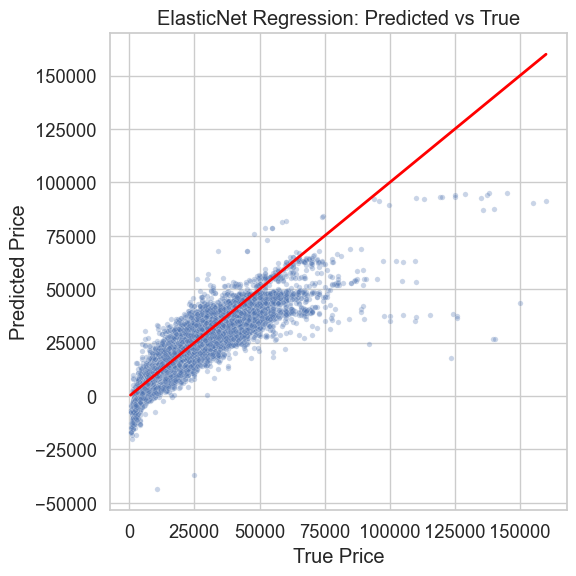

In [4]:
plot_pred_vs_true(en_final, "ElasticNet Regression")

### 4.2. Residuals vs Predicted (heteroscedasticity check)

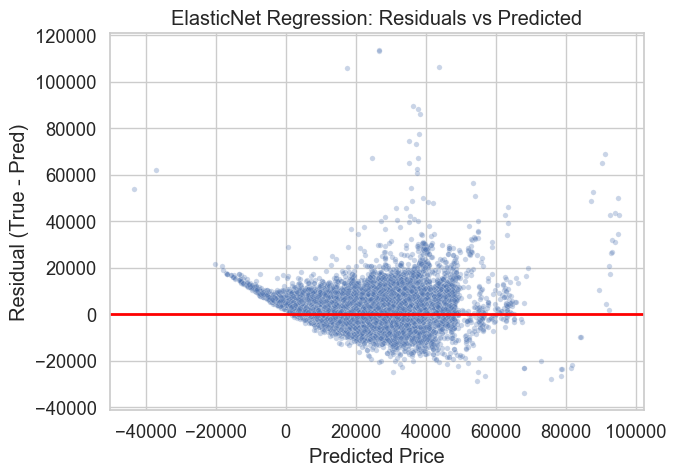

In [5]:
plot_residuals(en_final, "ElasticNet Regression")

### 4.3. Residual distribution

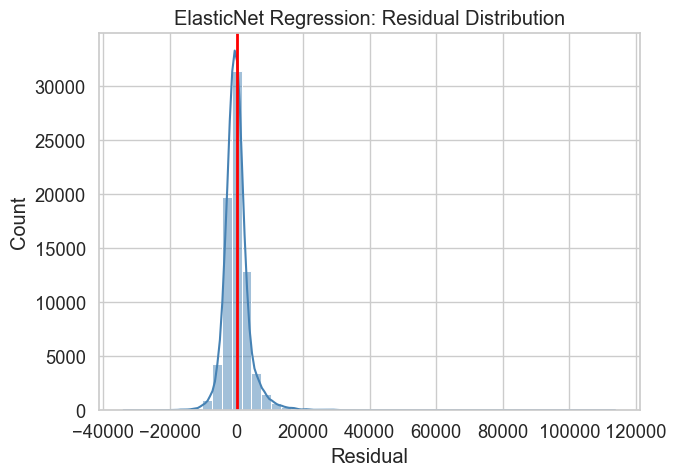

In [6]:
plot_residual_distribution(en_final, "ElasticNet Regression")

### 4.4. Permutation Importance

/var/folders/ts/9fy52qg56jz05nxpdkmswkzw0000gr/T/ipykernel_71204/2081930191.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=imp_df, palette="magma")


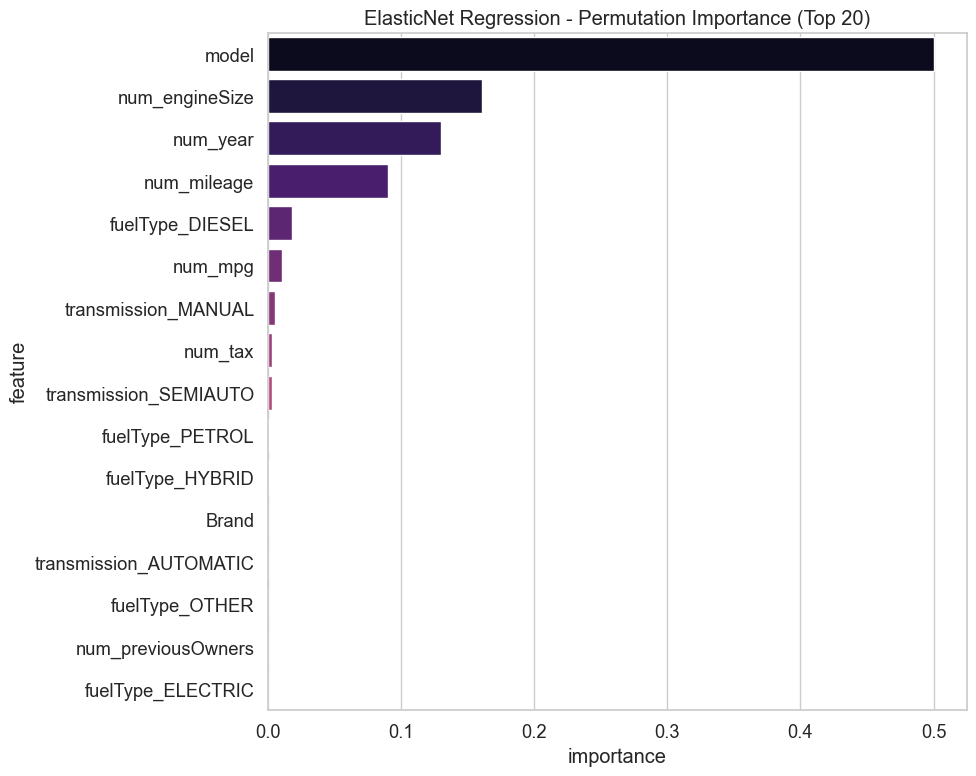

In [7]:
plot_permutation_importance(en_final, "ElasticNet Regression")

### 4.5. SHAP


SHAP for ElasticNet Regression (sample size = 2000)


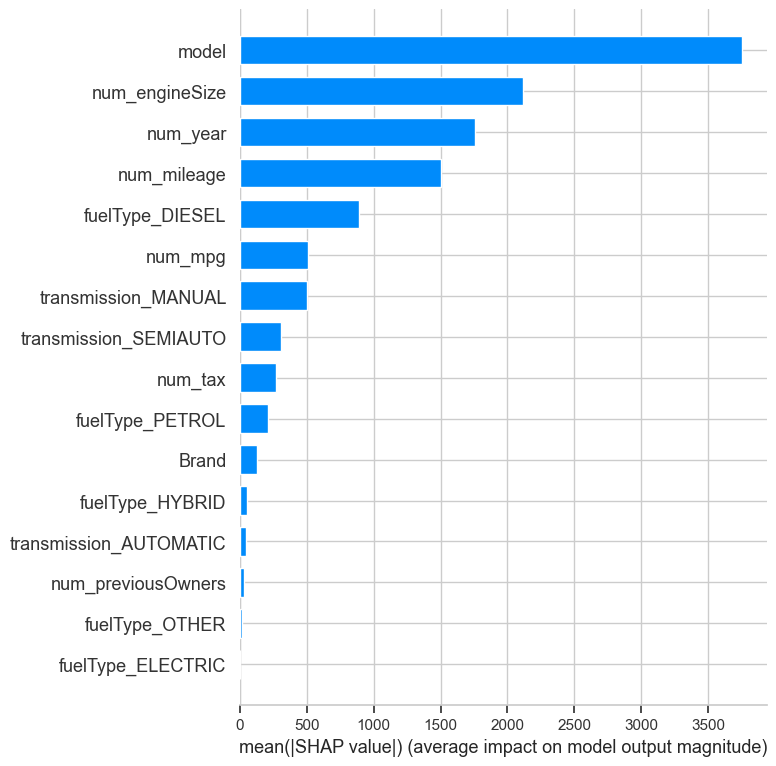

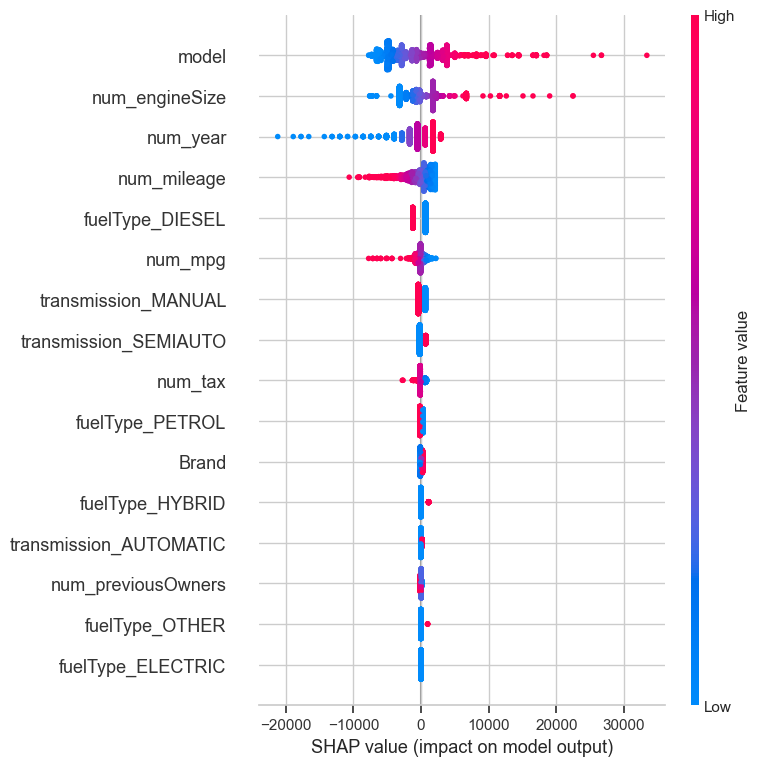

In [8]:
X_shap = X_full_final.copy()
X_shap = X_shap.astype(float)  # converts bool to 0/1 and ensures consistent dtype

apply_shap(en_final, X_shap, "ElasticNet Regression")